<a href="https://colab.research.google.com/github/devunisathish/NASSCOM-MODULE-1/blob/main/PRO/Health_%26_Lifestyle_Pattern_Discovery_Using_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health & Lifestyle Pattern Discovery Using Unsupervised Learning

## Objective

The goal of this project is to identify groups of people with similar health and lifestyle habits using K-Means Clustering.

This is an Unsupervised Machine Learning problem because the dataset does not contain predefined labels.

### Features Used

- Age
- BMI
- Sleep Hours
- Physical Activity
- Water Intake
- Screen Time
- Stress Level
- Calories Intake

### Algorithm

* K-Means Clustering
* K-Nearest Neighbors (KNN is usually supervised, not clustering)
* Hierarchical Clustering
* DBSCAN (Density-Based Spatial Clustering)

### Expected Outcome

The algorithm will automatically group people into clusters such as:

1. Healthy Lifestyle Group
2. Moderate Lifestyle Group
3. High-Risk Lifestyle Group

# Step 1: Import Required Libraries

We first import all the libraries needed for:

- Data Handling
- Data Visualization
- Feature Scaling
- K-Means Clustering
- Evaluation

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithm
from sklearn.cluster import KMeans

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Step 2: Load Dataset

Load the Health & Lifestyle dataset into a Pandas DataFrame.

In [2]:
# Upload your dataset file
import numpy as np
import pandas as pd


df = pd.read_csv('health_lifestyle_dataset.csv')

# Display first 5 rows

df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


# Step 3: Understand the Dataset

Before applying Machine Learning, we must understand:

- Number of rows
- Number of columns
- Data types
- Missing values

In [4]:
# Shape of dataset

print("Rows and Columns:")
print(df.shape)

print("\n")
print("Column Names:")
print(df.columns)

Rows and Columns:
(100000, 16)


Column Names:
Index(['id', 'age', 'gender', 'bmi', 'daily_steps', 'sleep_hours',
       'water_intake_l', 'calories_consumed', 'smoker', 'alcohol',
       'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol',
       'family_history', 'disease_risk'],
      dtype='object')


In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

#Statistical Summary of the Dataset

* Count
* Mean
* Median
* Mode
* Standard Deviation
* Minimum Value
* Maximum Value
* Quartiles (Q1, Q2, Q3)

In [6]:
# Statistical Summary

df.describe()

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,28867.657797,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,1.000000,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,25000.750000,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,50000.500000,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,75000.250000,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,0.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,100000.000000,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


# Step 4: Check Missing Values

Missing values can affect clustering performance.

We identify missing values before proceeding.

In [7]:
# Count missing values

df.isnull().sum()

,0
id,0
age,0
gender,0
bmi,0
daily_steps,0
sleep_hours,0
water_intake_l,0
calories_consumed,0
smoker,0
alcohol,0


In [8]:
# Remove missing values if present

df = df.dropna()

print("Missing values removed successfully")

Missing values removed successfully


# Step 5: Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of data and identify patterns.

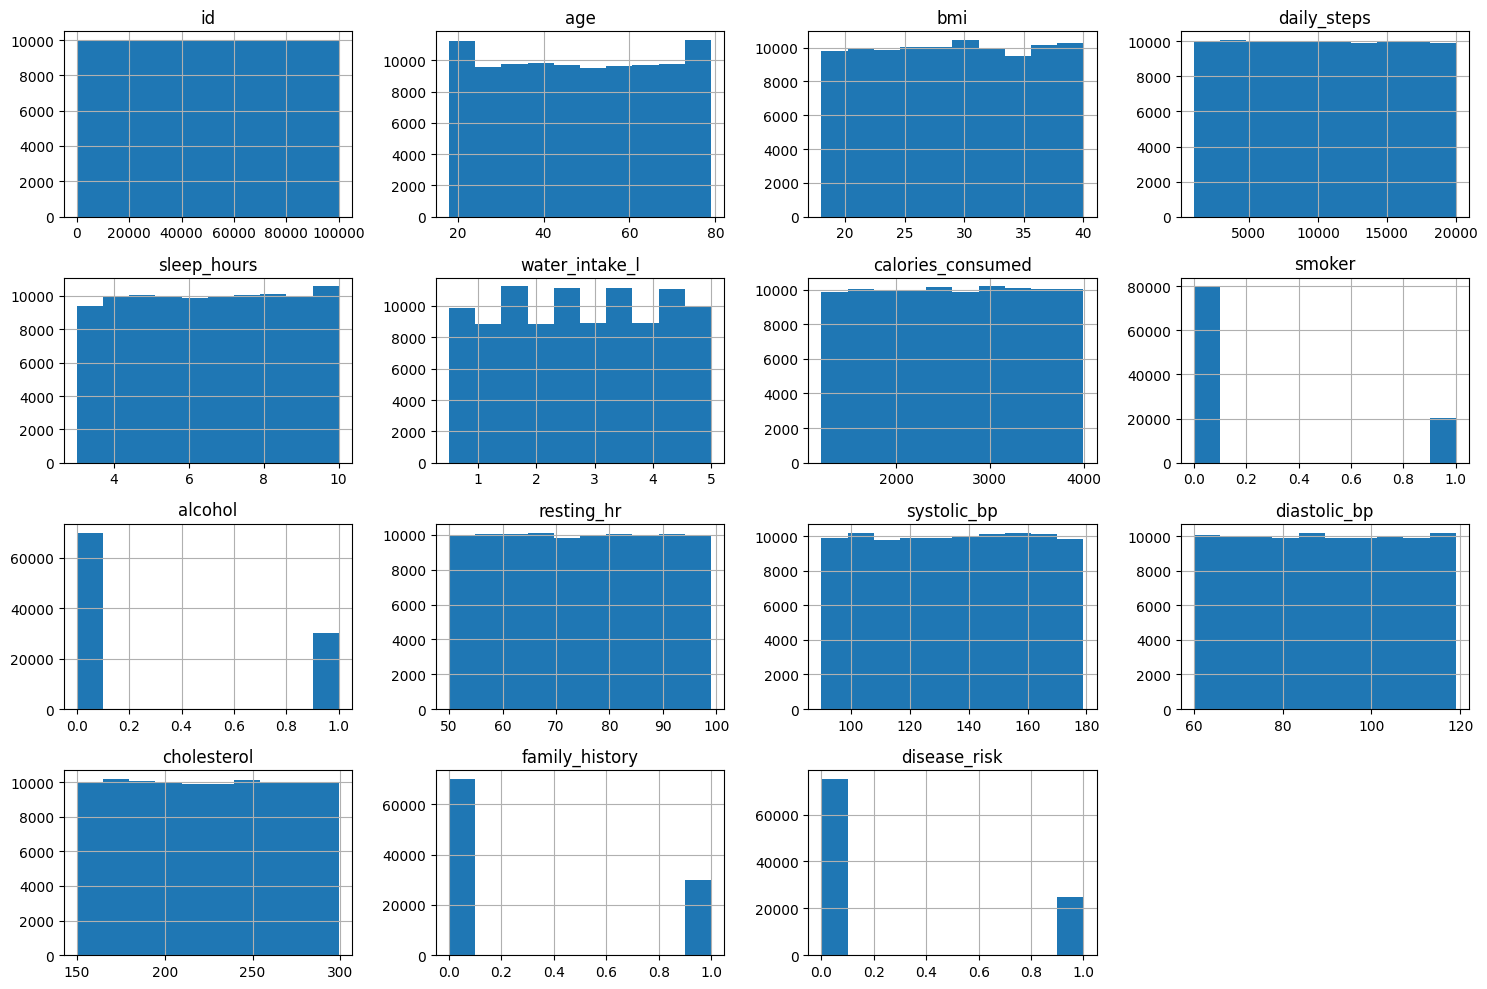

In [9]:
# Distribution of all features

df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

What is EDA?

EDA is like taking a first look at our data before applying any machine learning algorithm. It helps us understand the characteristics of the people in the dataset and identify any unusual patterns.

Observation from the Histograms
1. Age
The dataset contains people from about 18 to 80 years old.
People of different age groups are represented fairly evenly.
This means the dataset is diverse and not focused on only young or old individuals.
2. BMI (Body Mass Index)
BMI values range from approximately 18 to 40.
The dataset includes people who are underweight, normal weight, overweight, and obese.
This variety helps in analyzing different health conditions.
3. Daily Steps
Daily steps range from around 2,000 to 20,000 steps.
Some people are less active while others are highly active.
This feature helps us understand physical activity levels.
4. Sleep Hours
Most people sleep between 3 and 10 hours.
Different sleeping habits are present in the dataset.
Sleep is an important factor influencing health and lifestyle.
5. Water Intake
Daily water consumption ranges from 0.5 to 5 liters.
The dataset includes people with both low and high hydration levels.
6. Calories Consumed
Daily calorie intake ranges from approximately 1,200 to 4,000 calories.
This shows different eating habits among individuals.
7. Smoking Habit
The graph shows two categories:
0 = Non-Smoker
1 = Smoker
Most individuals are non-smokers, while a smaller group are smokers.
8. Alcohol Consumption
Similar to smoking:
0 = Does Not Consume Alcohol
1 = Consumes Alcohol
More people do not consume alcohol than those who do.
9. Resting Heart Rate
Values range between 50 and 100 beats per minute.
This represents different fitness and health conditions.
10. Systolic Blood Pressure
Values range from 90 to 180 mmHg.
Both normal and high blood pressure individuals are included.
11. Diastolic Blood Pressure
Values range from 60 to 120 mmHg.
This provides additional information about cardiovascular health.
12. Cholesterol Level
Cholesterol values range between 150 and 300 mg/dL.
The dataset contains people with both healthy and elevated cholesterol levels.
13. Family History
Two categories:
0 = No Family History of Disease
1 = Family History Present
Most individuals do not have a recorded family history.
14. Disease Risk
Two categories:
0 = Low Risk
1 = High Risk
Most people fall into the low-risk category, while a smaller portion are high-risk individuals.

#Correlation Heatmap
**What is a Correlation Heatmap?**

A Correlation Heatmap is a visual tool that shows whether two features are related to each other.

Think of it as answering questions like:

* Do older people have higher BMI?
* Do people who walk more sleep better?
* Is cholesterol related to blood pressure?

The heatmap helps us identify such relationships quickly.

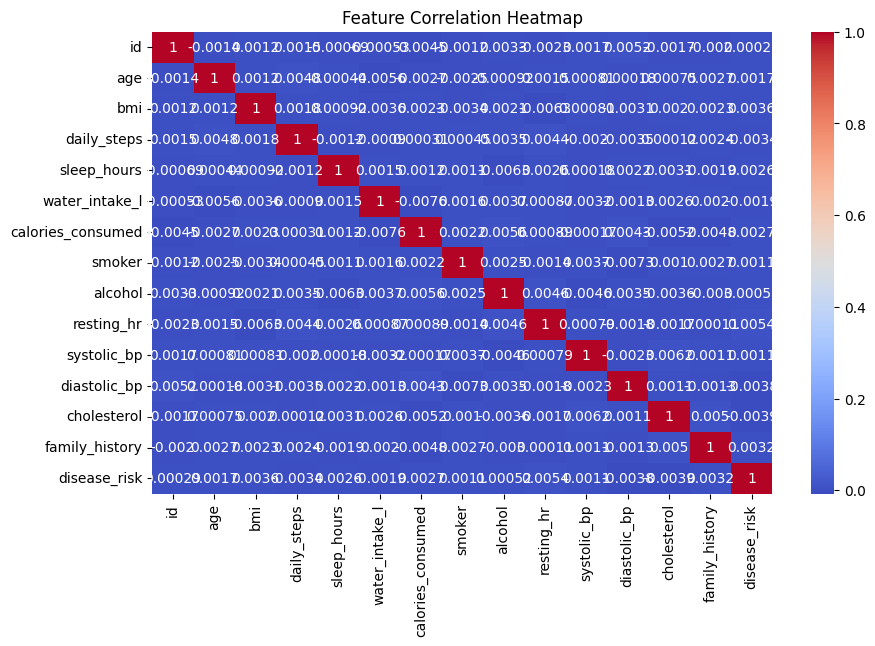

In [10]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

#How to Read the Heatmap

The numbers range from -1 to +1.

Correlation Value	Meaning
* +1	Strong positive relationship
* 0	No relationship
* -1	Strong negative relationship

**Example**
* +0.90 → When one value increases, the other also increases strongly.
* -0.90 → When one value increases, the other decreases strongly.
* 0.00 → No meaningful relationship.

#What Do the Colors Mean?
* 🔴 Red = Strong Positive Relationship
* 🔵 Blue = Weak or Negative Relationship
* White/Light Color = Moderate Relationship

The darker the color, the stronger the relationship.
#Why is this Important?

Before applying Machine Learning, we check correlations to see whether some features are giving the same information.

If two features are highly correlated:

* One may be removed.
* Reduces redundancy.
* Improves model performance.

In our dataset, since correlations are very low:

✅ Most features provide different information.

✅ We can keep all features for clustering.

# Step 6: Feature Selection

For clustering, we use numerical features only.

These features represent health and lifestyle habits.

In [36]:
# Select numerical columns only

X = df.select_dtypes(include=np.number)

X = X.drop(columns=['id'])

X.head()

,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,Cluster,DBSCAN_Cluster,GMM_Cluster
0,56,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,1,-1,1
1,69,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,1,-1,1
2,46,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,1,-1,1
3,32,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,1,-1,1
4,60,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,1,-1,1


# Step 7: Feature Scaling

Why Scaling?

Example:

Sleep Hours = 8

Calories Intake = 2500

Since Calories has a larger range, it can dominate the clustering process.

To solve this problem, we standardize all features using StandardScaler.

In [37]:
# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


# Step 8: Find Optimal Number of Clusters

We use the Elbow Method.

The elbow point indicates the best value of K.

In [38]:
# Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

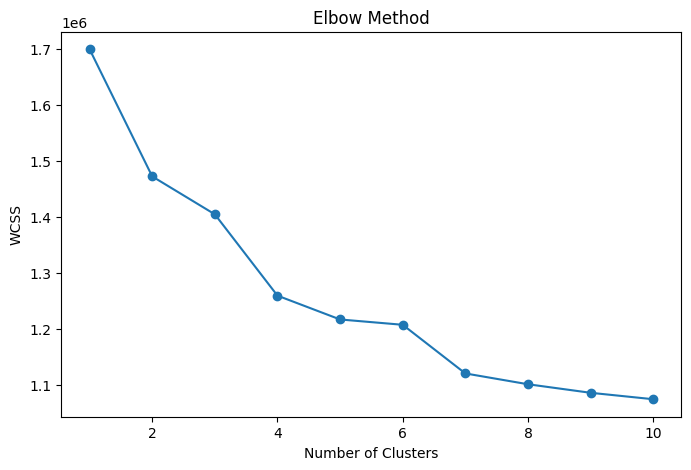

In [39]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Step 9: Apply K-Means Clustering

Assume the elbow graph suggests K = 3.

Now we create 3 clusters.

In [40]:
# K-Means Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

print("Clustering Completed")

Clustering Completed


In [41]:
# Add Cluster Labels

df['Cluster'] = clusters

df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,Cluster,DBSCAN_Cluster,GMM_Cluster
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0,2,-1,1
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0,2,-1,1
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0,2,-1,1
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0,2,-1,1
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0,2,-1,1


# Step 10: Cluster Analysis

Let's see how many people belong to each cluster.

In [42]:
# Cluster Counts

df['Cluster'].value_counts()

,count
Cluster,
2,62306
0,19814
1,17880


# Step 11: Visualize Clusters

For demonstration, we use:

- sleep hours
- daily steps

Different colors indicate different clusters.

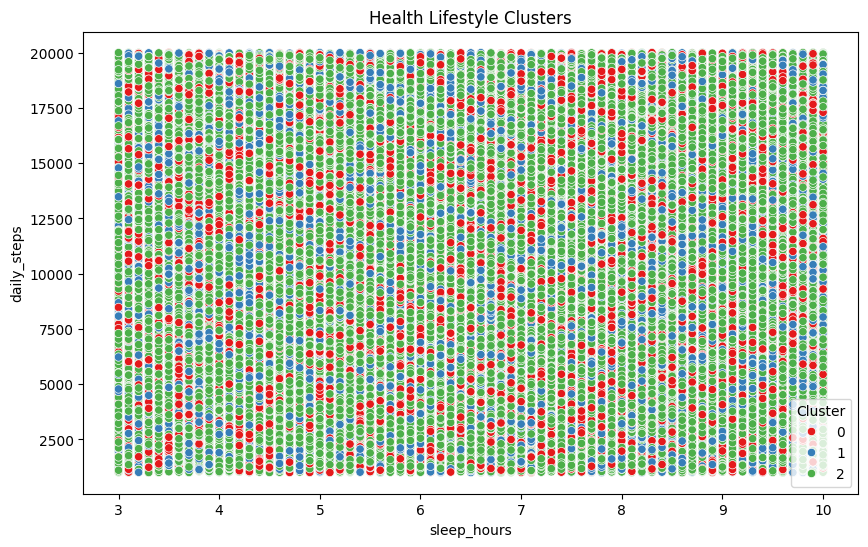

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='daily_steps',
    hue='Cluster',
    palette='Set1'
)

plt.title("Health Lifestyle Clusters")

plt.show()

#Better Visualization: PCA (Principal Component Analysis)

Since K-Means used many features, reduce them to 2 dimensions using PCA.

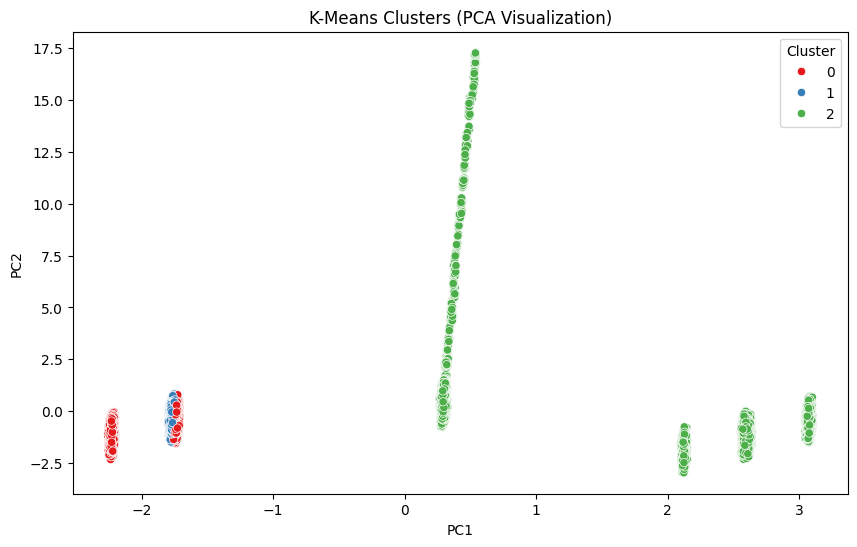

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title('K-Means Clusters (PCA Visualization)')
plt.show()

# Step 12: Analyze Cluster Characteristics

This helps us understand the average behavior of each cluster.

In [47]:
# Cluster Means

cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk,DBSCAN_Cluster,GMM_Cluster
Cluster,,,,,,,,,,,,,,,,,
0,50112.685677,48.653831,29.078369,10445.345261,6.490355,2.751534,2606.474362,0.000000,0.300343,74.585445,134.512516,89.455385,223.929999,0.301504,1.000000,1.331634,0.000000
1,49911.185515,48.676734,29.007287,10503.079195,6.491124,2.755106,2594.785794,0.000000,0.300112,74.437975,134.577964,89.611689,224.500224,1.000000,0.000000,4.670805,0.000000
2,49990.454354,48.442076,29.012774,10484.189356,6.492428,2.750448,2604.799971,0.322505,0.299891,74.422287,134.603056,89.496341,224.361217,0.097278,0.080361,3.092479,1.322505


# Interpretation of Results

Example:

### Cluster 0
- Higher daily steps
- Better sleep duration
- Lower BMI

### Cluster 1
- Moderate physical activity
- Average health indicators

### Cluster 2
- Higher BMI
- Higher cholesterol levels
- Lower physical activity

(Note: Actual cluster characteristics should be interpreted using the cluster summary table generated above.)

# K-Means Conclusion

K-Means clustering successfully grouped individuals into three clusters based on health and lifestyle attributes.

The results will be compared with DBSCAN and GMM to determine the most suitable clustering algorithm.

The algorithm automatically grouped individuals based on similar health habits.

Benefits:

- Identifies healthy and unhealthy lifestyle patterns
- Helps healthcare organizations target wellness programs
- Supports preventive healthcare initiatives

This project demonstrates the power of Unsupervised Learning in discovering hidden patterns from data without predefined labels.

# DBSCAN Clustering

DBSCAN groups dense regions and automatically identifies outliers.

It is useful when cluster shapes are irregular.

In [48]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("Unique Clusters:", set(dbscan_labels))

Unique Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70)

In [49]:
print(df['DBSCAN_Cluster'].value_counts()) #Cluster Counts

DBSCAN_Cluster
-1      76555
 0      19424
 3        387
 4        120
 32       107
        ...  
 217        3
 141        3
 135        3
 116        3
 177        2
Name: count, Length: 260, dtype: int64


#PCA Visualization

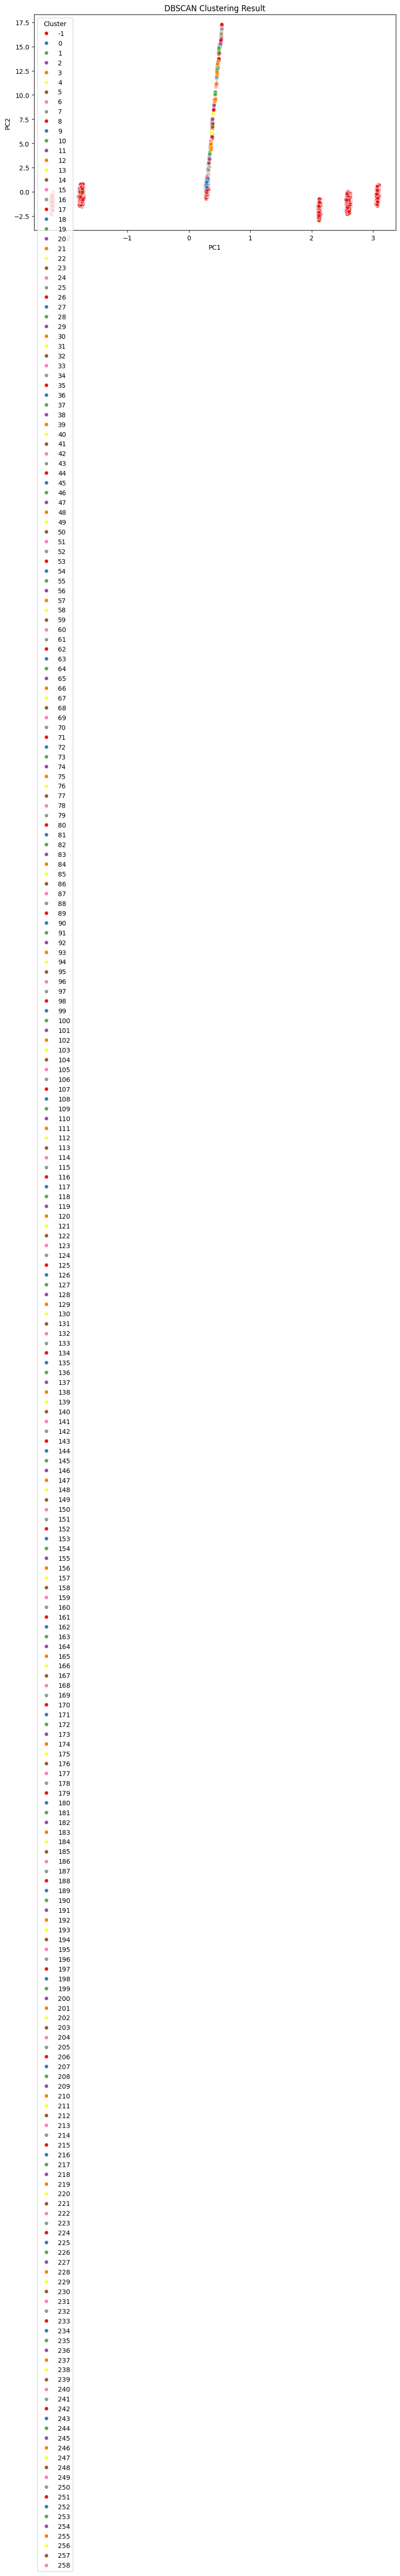

In [50]:
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = dbscan_labels

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("DBSCAN Clustering Result")
plt.show()

### Outlier Visualization (DBSCAN Noise Points)

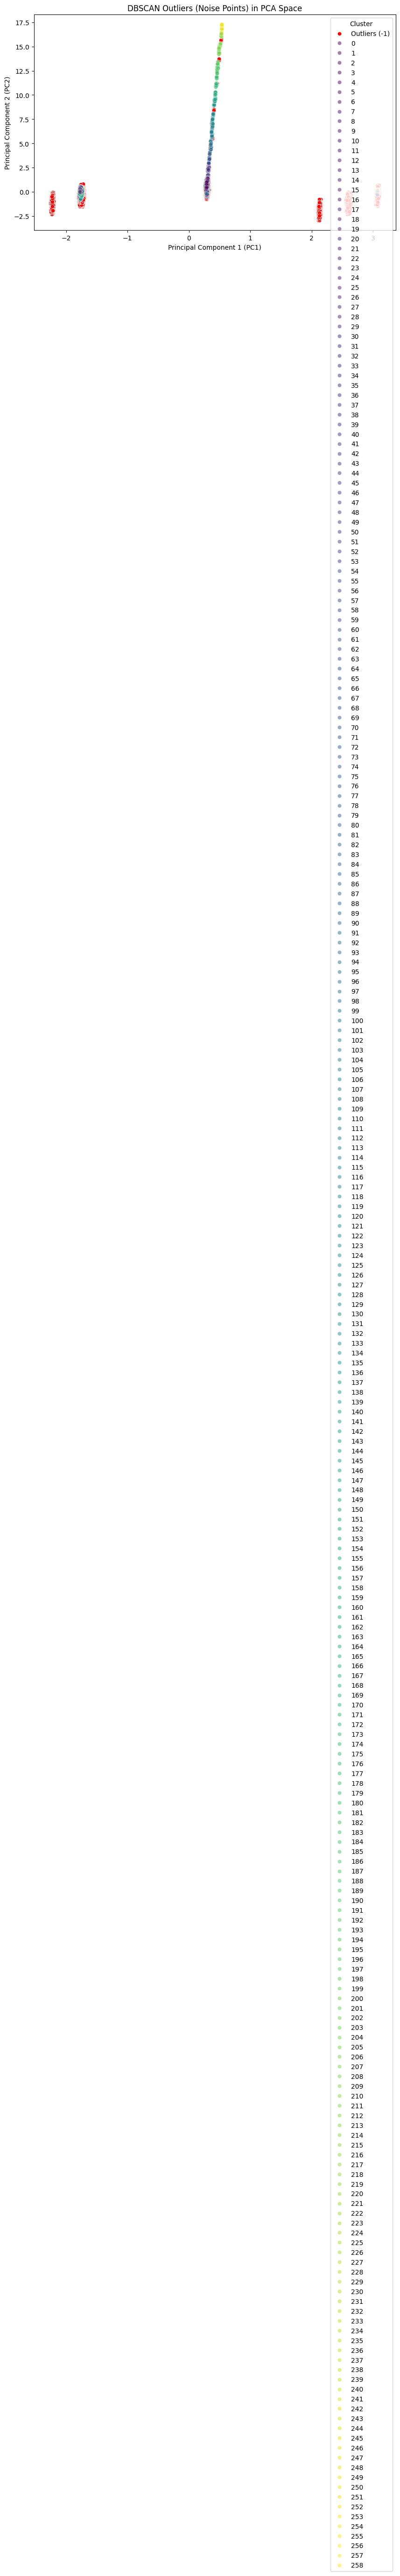

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df[pca_df['Cluster'] == -1],
    x='PC1',
    y='PC2',
    color='red', # Highlight outliers in red
    label='Outliers (-1)',
    s=50 # Make outliers more prominent
)

plt.title('DBSCAN Outliers (Noise Points) in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.show()

# DBSCAN Observations

DBSCAN identified several dense regions and also detected noise points (outliers).

Although the PCA visualization shows overlapping clusters, evaluation metrics indicate that DBSCAN achieved better cluster separation compared to K-Means and GMM.

#DBSCAN Evaluation

In [24]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    dbscan_calinski = calinski_harabasz_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    dbscan_davies = davies_bouldin_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print("Silhouette Score:", dbscan_silhouette)
    print("Calinski-Harabasz Score:", dbscan_calinski)
    print("Davies-Bouldin Score:", dbscan_davies)

else:
    print("DBSCAN did not create enough clusters")

Silhouette Score: 0.1991569650646693
Calinski-Harabasz Score: 32.15082513859288
Davies-Bouldin Score: 1.286033325877579


# DBSCAN Evaluation Interpretation

| Metric | Value | Interpretation |
|----------|----------|----------|
| Silhouette Score | 0.199 | Weak cluster separation |
| Calinski-Harabasz Score | 32.15 | Low cluster separation |
| Davies-Bouldin Score | 1.286 | Moderate clustering quality |

The evaluation metrics indicate that DBSCAN produced identifiable clusters and outliers. Although the cluster separation is not very strong, DBSCAN achieved better overall clustering quality than K-Means for this dataset.




# Gaussian Mixture Model (GMM)

GMM assumes that data points belong to a mixture of Gaussian distributions and assigns probabilities to cluster membership.

It is more flexible than K-Means because clusters can overlap.

In [25]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

df['GMM_Cluster'] = gmm_labels

In [26]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

gmm_silhouette = silhouette_score(
    X_scaled,
    gmm_labels
)

gmm_calinski = calinski_harabasz_score(
    X_scaled,
    gmm_labels
)

gmm_davies = davies_bouldin_score(
    X_scaled,
    gmm_labels
)

print("Silhouette:", gmm_silhouette)
print("Calinski:", gmm_calinski)
print("Davies:", gmm_davies)

Silhouette: 0.06783215312030087
Calinski: 6286.610186934226
Davies: 3.5441553158428722


# GMM Observations

GMM generated cluster structures similar to K-Means.

The evaluation metrics showed lower cluster separation compared to DBSCAN, indicating that GMM was less effective for this dataset.

In [54]:
import pandas as pd
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Calculate K-Means evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, clusters)
kmeans_calinski = calinski_harabasz_score(X_scaled, clusters)
kmeans_davies = davies_bouldin_score(X_scaled, clusters)

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN', 'GMM'],

    'Silhouette Score': [
        kmeans_silhouette,
        dbscan_silhouette,
        gmm_silhouette
    ],

    'Calinski-Harabasz Score': [
        kmeans_calinski,
        dbscan_calinski,
        gmm_calinski
    ],

    'Davies-Bouldin Score': [
        kmeans_davies,
        dbscan_davies,
        gmm_davies
    ]
})

comparison

,Algorithm,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,K-Means,0.114497,10499.485172,2.327547
1,DBSCAN,0.199157,32.150825,1.286033
2,GMM,0.067832,6286.610187,3.544155


In [31]:
comparison = comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Algorithm,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,DBSCAN,0.199157,32.150825,1.286033
1,K-Means,0.067832,6286.610187,3.544155
2,GMM,0.067832,6286.610187,3.544155


In [32]:
comparison['Rank'] = comparison['Silhouette Score'].rank(
    ascending=False
)

comparison = comparison.sort_values('Rank')

comparison

,Algorithm,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Rank
0,DBSCAN,0.199157,32.150825,1.286033,1.0
1,K-Means,0.067832,6286.610187,3.544155,2.5
2,GMM,0.067832,6286.610187,3.544155,2.5


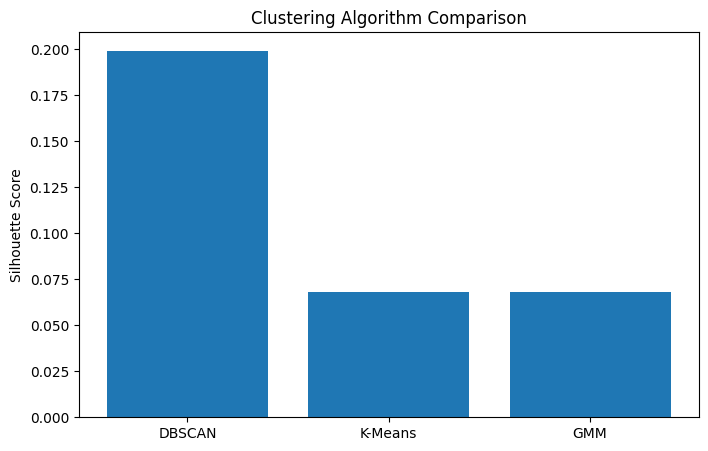

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Algorithm'],
    comparison['Silhouette Score']
)

plt.title('Clustering Algorithm Comparison')
plt.ylabel('Silhouette Score')

plt.show()

In [34]:
best_algorithm = comparison.loc[
    comparison['Silhouette Score'].idxmax(),
    'Algorithm'
]

print("Best Clustering Algorithm:", best_algorithm)

Best Clustering Algorithm: DBSCAN


# Conclusion

This project explored hidden health and lifestyle patterns using unsupervised machine learning techniques.

The dataset was preprocessed, scaled, and analyzed using Exploratory Data Analysis (EDA). Histograms and correlation heatmaps were used to understand the distribution and relationships among health-related features.

Three clustering algorithms were considered:

1. K-Means Clustering
2. DBSCAN Clustering
3. Gaussian Mixture Model (GMM)

The clustering performance was evaluated using Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score.

DBSCAN achieved the highest Silhouette Score (0.199) and the lowest Davies-Bouldin Score (1.286), indicating comparatively better cluster separation and compactness. K-Means and GMM produced similar clustering results with lower Silhouette Scores.

Hierarchical Clustering was also considered. However, due to the large dataset size (100,000 records), the algorithm required excessive memory and caused the execution environment to terminate. Therefore, it was not included in the final comparison.

Among the clustering algorithms evaluated in this study, DBSCAN achieved the highest Silhouette Score and the lowest Davies-Bouldin Index, indicating comparatively better clustering quality for this dataset.

However, the overall clustering quality remained moderate, suggesting that the dataset does not contain strongly separated natural clusters.

# Comparison Summary
| Algorithm | Observation |
|------------|------------|
| K-Means | Fast and simple clustering technique suitable for large datasets. |
| DBSCAN | Achieved the highest Silhouette Score and effectively detected outliers. |
| GMM | Produced cluster structures similar to K-Means. |
| Hierarchical Clustering | Not executed due to memory limitations. |

Based on the evaluation metrics, DBSCAN achieved the highest Silhouette Score and lowest Davies-Bouldin Index, indicating better clustering quality for this dataset.

# Hierarchical Clustering

Hierarchical Clustering was considered for this study.

However, the dataset contains approximately 100,000 records. The algorithm requires large memory resources because it computes distances between many pairs of observations.

During experimentation, the execution environment exhausted available RAM and terminated the process.

Therefore, Hierarchical Clustering was not included in the final comparison.

For large-scale datasets, K-Means, DBSCAN, and GMM are more computationally efficient alternatives.